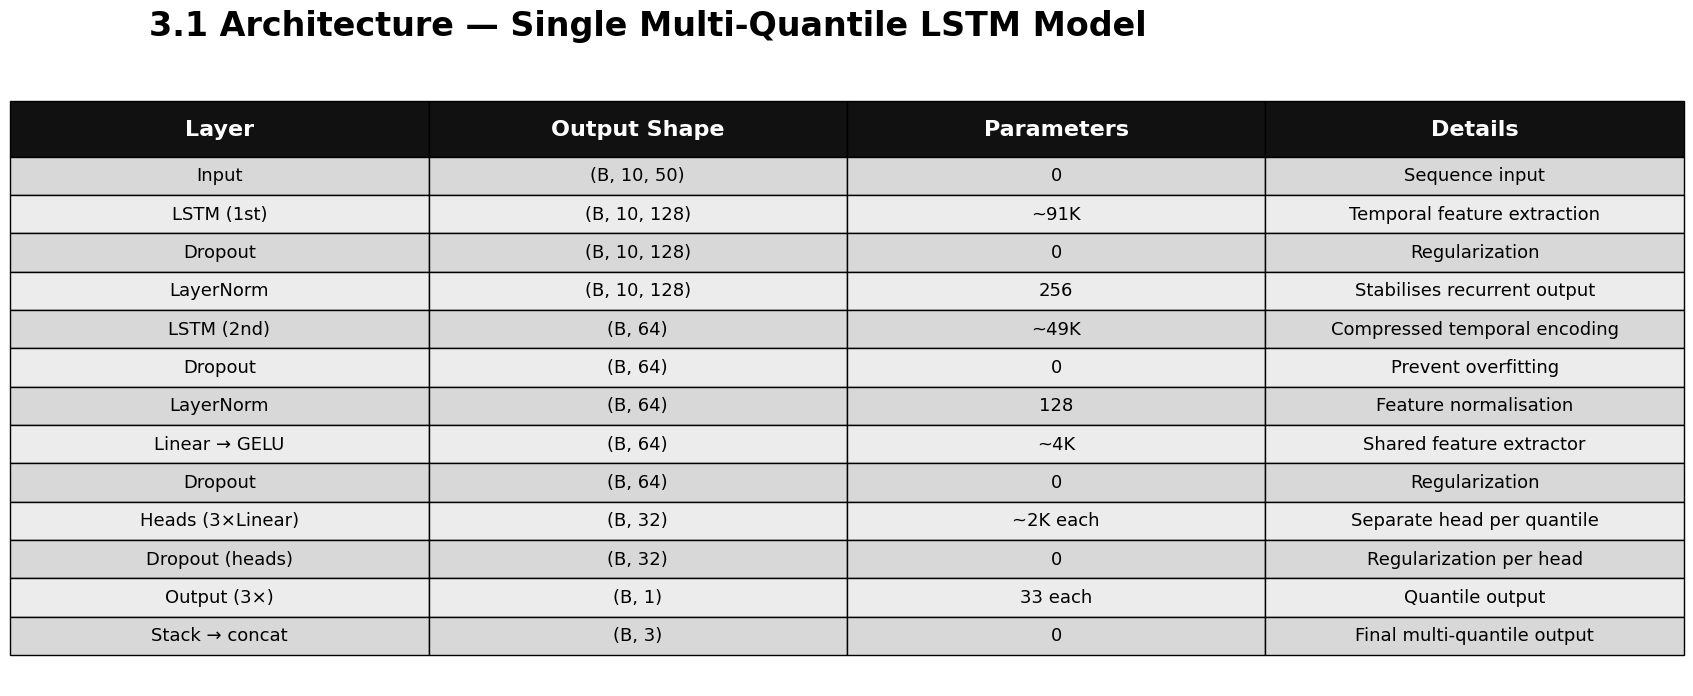

In [1]:
# =========================================================
# TABLE 1 : LSTM SINGLE-MODEL ARCHITECTURE
# =========================================================

import matplotlib.pyplot as plt

table_data = [
    ["Input", "(B, 10, 50)", "0", "Sequence input"],
    ["LSTM (1st)", "(B, 10, 128)", "~91K", "Temporal feature extraction"],
    ["Dropout", "(B, 10, 128)", "0", "Regularization"],
    ["LayerNorm", "(B, 10, 128)", "256", "Stabilises recurrent output"],
    ["LSTM (2nd)", "(B, 64)", "~49K", "Compressed temporal encoding"],
    ["Dropout", "(B, 64)", "0", "Prevent overfitting"],
    ["LayerNorm", "(B, 64)", "128", "Feature normalisation"],
    ["Linear → GELU", "(B, 64)", "~4K", "Shared feature extractor"],
    ["Dropout", "(B, 64)", "0", "Regularization"],
    ["Heads (3×Linear)", "(B, 32)", "~2K each", "Separate head per quantile"],
    ["Dropout (heads)", "(B, 32)", "0", "Regularization per head"],
    ["Output (3×)", "(B, 1)", "33 each", "Quantile output"],
    ["Stack → concat", "(B, 3)", "0", "Final multi-quantile output"],
]

columns = [
    "Layer",
    "Output Shape",
    "Parameters",
    "Details"
]

fig, ax = plt.subplots(figsize=(18, 8))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.2, 2.3)

# Header style
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#111111")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    cell.set_height(0.09)

# Body style
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ECECEC")
    else:
        cell.set_facecolor("#D8D8D8")

# Title
plt.title(
    "3.1 Architecture — Single Multi-Quantile LSTM Model",
    fontsize=24,
    fontweight='bold',
    loc='left',
    pad=25
)

plt.savefig(
    "lstm_architecture_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

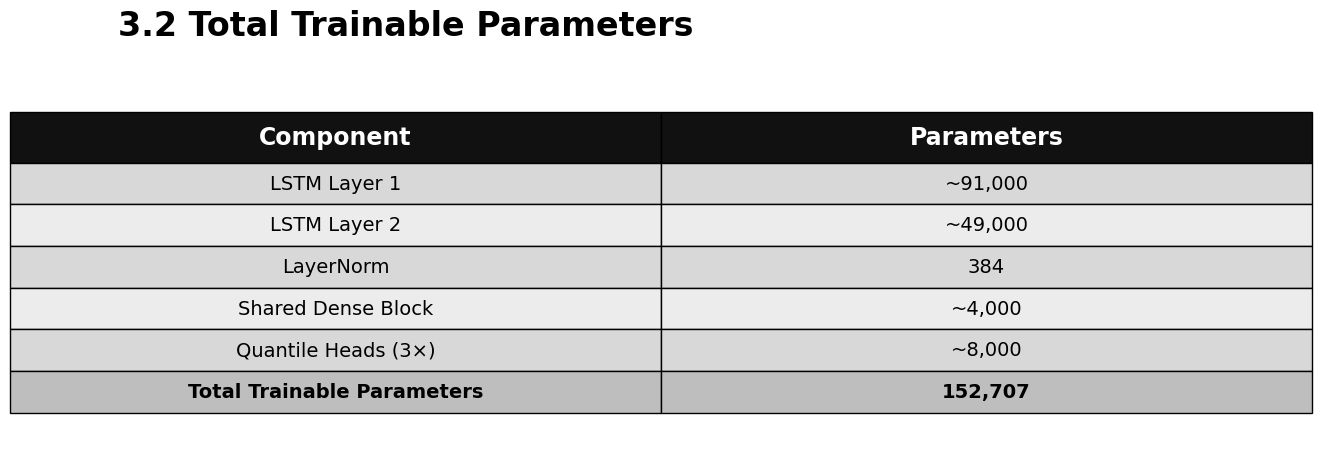

In [6]:
# =========================================================
# TABLE 2 : TOTAL TRAINABLE PARAMETERS
# =========================================================

import matplotlib.pyplot as plt

table_data = [
    ["LSTM Layer 1", "~91,000"],
    ["LSTM Layer 2", "~49,000"],
    ["LayerNorm", "384"],
    ["Shared Dense Block", "~4,000"],
    ["Quantile Heads (3×)", "~8,000"],
    ["Total Trainable Parameters", "152,707"],
]

columns = [
    "Component",
    "Parameters"
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1.2, 2.5)

# Header
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#111111")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=17
    )

    cell.set_height(0.13)

# Body
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ECECEC")
    else:
        cell.set_facecolor("#D8D8D8")

# Highlight last row
last_row = len(table_data)

for col in range(len(columns)):
    tbl[(last_row, col)].set_facecolor("#BEBEBE")
    tbl[(last_row, col)].set_text_props(weight='bold')

plt.title(
    "3.2 Total Trainable Parameters",
    fontsize=24,
    fontweight='bold',
    loc='left',
    pad=25
)

plt.savefig(
    "lstm_trainable_parameters_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

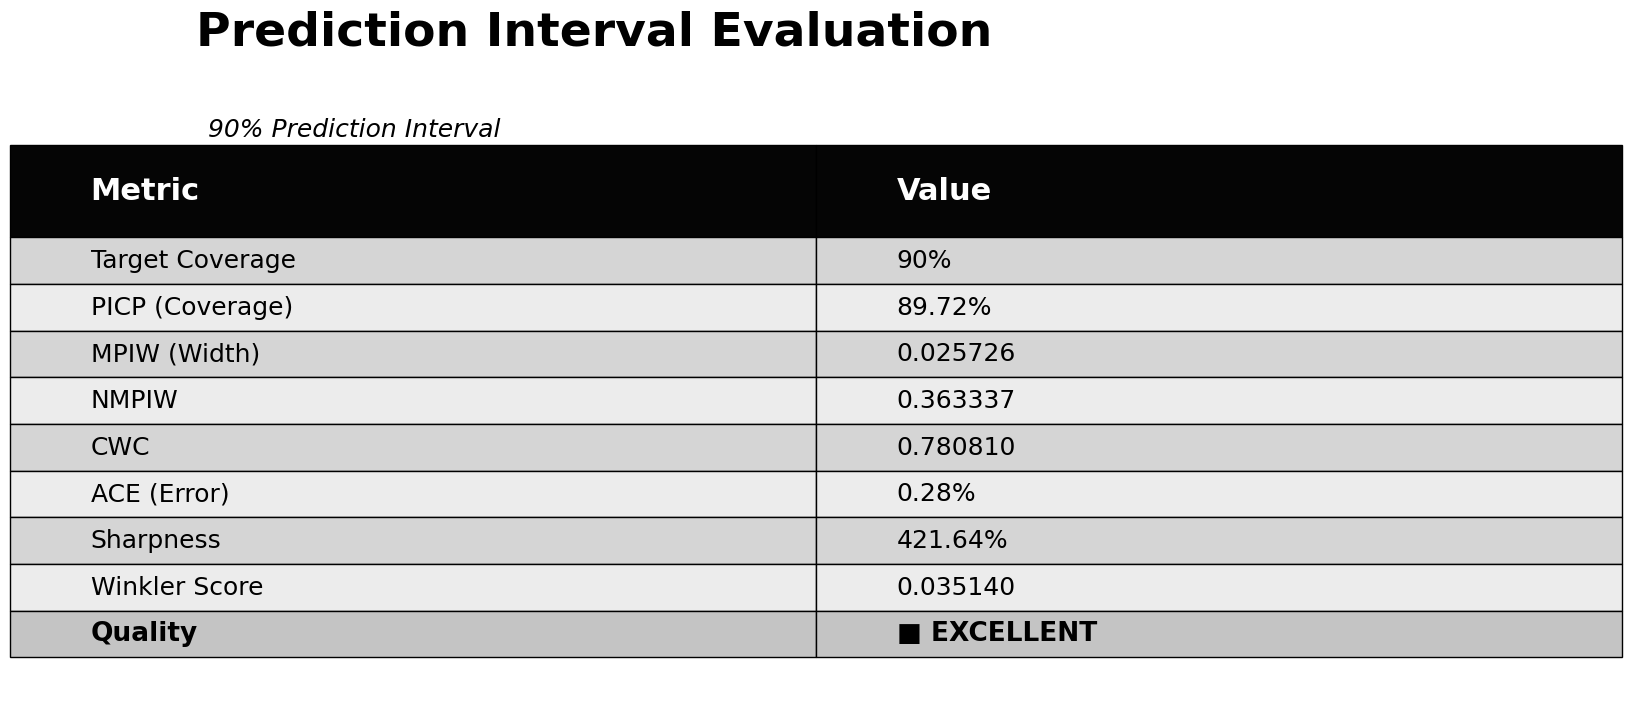

Saved → prediction_interval_evaluation.png


In [4]:
import matplotlib.pyplot as plt

# =========================================================
# PREDICTION INTERVAL EVALUATION TABLE
# =========================================================

table_data = [
    ["Target Coverage", "90%"],
    ["PICP (Coverage)", "89.72%"],
    ["MPIW (Width)", "0.025726"],
    ["NMPIW", "0.363337"],
    ["CWC", "0.780810"],
    ["ACE (Error)", "0.28%"],
    ["Sharpness", "421.64%"],
    ["Winkler Score", "0.035140"],
    ["Quality", "■ EXCELLENT"],
]

columns = [
    "Metric",
    "Value"
]

# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(16, 8))

ax.axis('off')

# =========================================================
# TABLE
# =========================================================

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='left',
    colLoc='left',
    loc='center'
)

# =========================================================
# STYLE
# =========================================================

tbl.auto_set_font_size(False)

tbl.set_fontsize(18)

tbl.scale(1.3, 2.8)

# =========================================================
# HEADER STYLE
# =========================================================

for col in range(len(columns)):

    cell = tbl[(0, col)]

    cell.set_facecolor("#050505")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=22
    )

    cell.set_height(0.15)

# =========================================================
# BODY STYLE
# =========================================================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    # alternating rows
    if row % 2 == 0:
        cell.set_facecolor("#ECECEC")
    else:
        cell.set_facecolor("#D5D5D5")

    # font size
    cell.set_text_props(fontsize=18)

# =========================================================
# HIGHLIGHT QUALITY ROW
# =========================================================

last_row = len(table_data)

for col in range(len(columns)):

    tbl[(last_row, col)].set_facecolor("#C4C4C4")

    tbl[(last_row, col)].set_text_props(
        weight='bold',
        fontsize=19
    )

# =========================================================
# TITLE
# =========================================================

plt.title(
    "Prediction Interval Evaluation",
    fontsize=34,
    fontweight='bold',
    loc='left',
    pad=35
)

# =========================================================
# SUBTITLE
# =========================================================

plt.text(
    0.01,
    0.93,
    "90% Prediction Interval",
    fontsize=18,
    style='italic',
    transform=ax.transAxes
)

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    "prediction_interval_evaluation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → prediction_interval_evaluation.png")

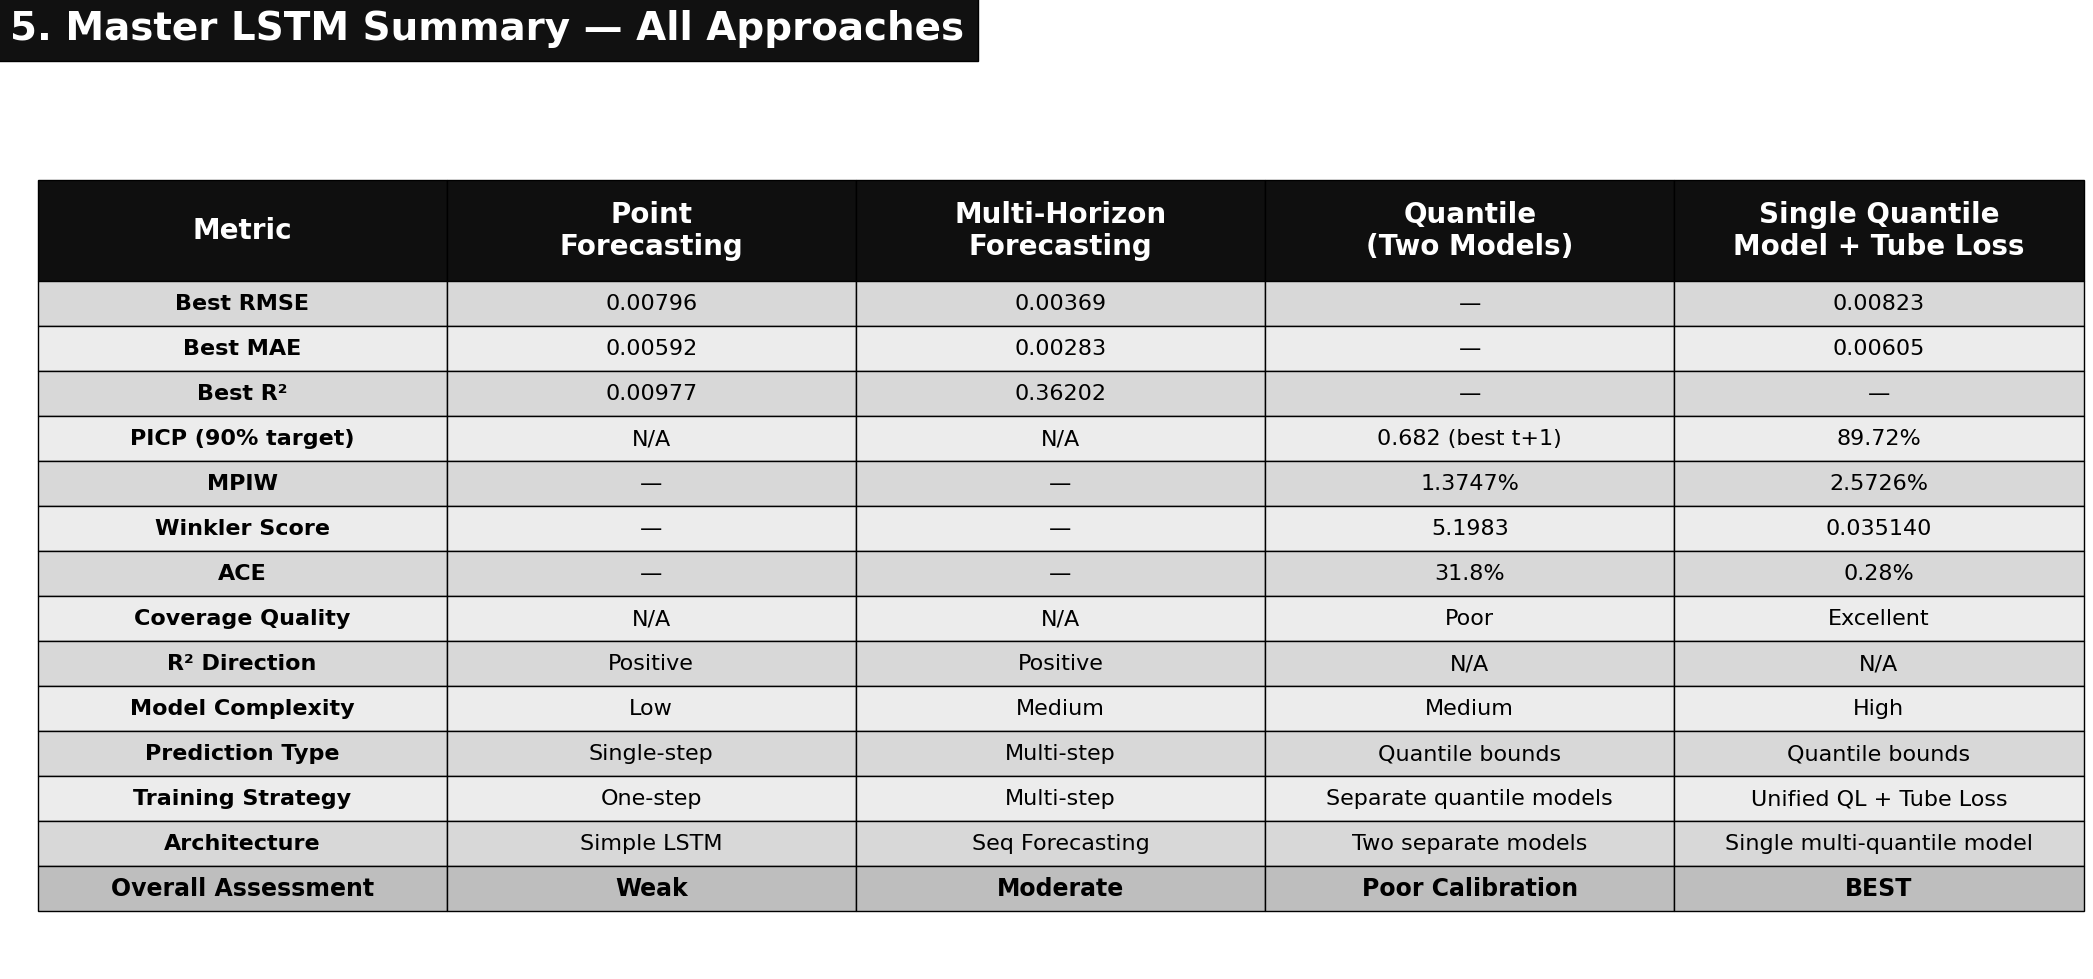

Saved → master_lstm_summary_all_approaches.png


In [5]:
import matplotlib.pyplot as plt

# =========================================================
# MASTER LSTM SUMMARY — ALL APPROACHES
# =========================================================

table_data = [

    ["Best RMSE",
     "0.00796",
     "0.00369",
     "—",
     "0.00823"],

    ["Best MAE",
     "0.00592",
     "0.00283",
     "—",
     "0.00605"],

    ["Best R²",
     "0.00977",
     "0.36202",
     "—",
     "—"],

    ["PICP (90% target)",
     "N/A",
     "N/A",
     "0.682 (best t+1)",
     "89.72%"],

    ["MPIW",
     "—",
     "—",
     "1.3747%",
     "2.5726%"],

    ["Winkler Score",
     "—",
     "—",
     "5.1983",
     "0.035140"],

    ["ACE",
     "—",
     "—",
     "31.8%",
     "0.28%"],

    ["Coverage Quality",
     "N/A",
     "N/A",
     "Poor",
     "Excellent"],

    ["R² Direction",
     "Positive",
     "Positive",
     "N/A",
     "N/A"],

    ["Model Complexity",
     "Low",
     "Medium",
     "Medium",
     "High"],

    ["Prediction Type",
     "Single-step",
     "Multi-step",
     "Quantile bounds",
     "Quantile bounds"],

    ["Training Strategy",
     "One-step",
     "Multi-step",
     "Separate quantile models",
     "Unified QL + Tube Loss"],

    ["Architecture",
     "Simple LSTM",
     "Seq Forecasting",
     "Two separate models",
     "Single multi-quantile model"],

    ["Overall Assessment",
     "Weak",
     "Moderate",
     "Poor Calibration",
     "BEST"]
]

# =========================================================
# COLUMN HEADERS
# =========================================================

columns = [
    "Metric",
    "Point\nForecasting",
    "Multi-Horizon\nForecasting",
    "Quantile\n(Two Models)",
    "Single Quantile\nModel + Tube Loss"
]

# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(22, 11))

ax.axis('off')

# =========================================================
# TABLE
# =========================================================

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# =========================================================
# FONT + SCALE
# =========================================================

tbl.auto_set_font_size(False)

tbl.set_fontsize(16)

tbl.scale(1.2, 2.7)

# =========================================================
# HEADER STYLE
# =========================================================

for col in range(len(columns)):

    cell = tbl[(0, col)]

    cell.set_facecolor("#0F0F0F")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=20
    )

    cell.set_height(0.12)

# =========================================================
# BODY STYLE
# =========================================================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    # alternating rows
    if row % 2 == 0:
        cell.set_facecolor("#ECECEC")
    else:
        cell.set_facecolor("#D8D8D8")

    # first column bold
    if col == 0:
        cell.set_text_props(weight='bold')

# =========================================================
# HIGHLIGHT FINAL ROW
# =========================================================

last_row = len(table_data)

for col in range(len(columns)):

    tbl[(last_row, col)].set_facecolor("#BEBEBE")

    tbl[(last_row, col)].set_text_props(
        weight='bold',
        fontsize=17
    )

# =========================================================
# TITLE BAR
# =========================================================

plt.gcf().text(
    0.035,
    0.955,
    "5. Master LSTM Summary — All Approaches",
    fontsize=28,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor='#111111',
        edgecolor='black',
        boxstyle='square,pad=0.35'
    )
)

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    "master_lstm_summary_all_approaches.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → master_lstm_summary_all_approaches.png")